# Parameter identifiability of the Pol II pools model

This notebook runs four analyses:

1. Repeated fitting from 250 random initial conditions, to ask whether the optimum is unique.
2. Profile likelihood for each of the 5 parameters, and for the two derived saturation
   levels $N_{\text{ss}}/(K_{\text{m}(NP)}+N_{\text{ss}})$ and
   $P_{\text{ss}}/(K_{\text{m}(PE)}+P_{\text{ss}})$ at $T=1$.
3. Bootstrap resampling, to gauge the variability of the point estimates.
4. Influence of the two dxChIP-seq measurements, by profiling over their values.

In [1]:
import os, sys, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

sys.path.append(os.getcwd())
os.environ.setdefault("POLII_DATA", "../data")
import polii_model as pm

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.sans-serif": ["Arial", "DejaVu Sans", "sans-serif"],
        "font.size": 8,
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "axes.linewidth": 1.0,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
    }
)

FIT = dict(w_P=3.0, pt_fraction=0.8)
data = pm.load_data()
print({k: np.shape(v) for k, v in data.items()})

# pool colours, matching the main figures
C_NP = "#5bba47"  # N->P, the promoter-proximal (paused) pool
C_PE = "xkcd:medium blue"  # P->E, the elongating pool

{'T_E': (71,), 'E': (71,), 'E_block': (71,), 'E3_sd': (5,), 'E_sd': (71,), 'E_fit': (71,), 'T_B': (33,), 'B': (33,), 'B_block': (33,), 'T_P': (3,), 'P': (3,), 'P_fit': (3,)}


## Refactoring the solver for fast steady-state evaluation

`polii_model.steady_state` replaces the multi-initial-guess `scipy.optimize.root`
search of the original notebook with a single scalar root-find in $P_{\text{ss}}$.
This section first shows that the steady state is unique and then confirms
numerically that the two solvers agree.

### The model

$$\frac{dN}{dt}=k_{PN}P+k_{EN}E-\frac{V_{\text{max}(NP)}N}{K_{\text{m}(NP)}+N}$$

$$\frac{dP}{dt}=\frac{V_{\text{max}(NP)}N}{K_{\text{m}(NP)}+N}-k_{PN}P-\frac{V_{\text{max}(PE)}P}{K_{\text{m}(PE)}+P}$$

$$\frac{dE}{dt}=\frac{V_{\text{max}(PE)}P}{K_{\text{m}(PE)}+P}-k_{EN}E$$

with $T=N+P+E$ conserved and $k_{EN}=1$ fixed to set the timescale. The three
right-hand sides sum identically to zero, so only two of the three steady-state
conditions are independent.

Throughout, $V_{\text{max}(NP)}$, $V_{\text{max}(PE)}$, $K_{\text{m}(NP)}$,
$K_{\text{m}(PE)}$, $k_{EN}>0$, $k_{PN}\geq 0$ and $T>0$


### Eliminate $E_{\text{ss}}$

Setting $dE/dt=0$,

$$E_{\text{ss}}=\frac{V_{\text{max}(PE)}P_{\text{ss}}}{k_{EN}\left(K_{\text{m}(PE)}+P_{\text{ss}}\right)}\equiv\varepsilon(P_{\text{ss}}).$$

$\varepsilon$ is strictly increasing and bounded, since

$$\varepsilon(0)=0,\qquad \varepsilon'(P)=\frac{V_{\text{max}(PE)}K_{\text{m}(PE)}}{k_{EN}\left(K_{\text{m}(PE)}+P\right)^{2}}>0,\qquad \varepsilon(P)\longrightarrow\frac{V_{\text{max}(PE)}}{k_{EN}}\ \ (P\to\infty).$$

### Eliminate $N_{\text{ss}}$

Conservation gives

$$N_{\text{ss}}=T-P_{\text{ss}}-\varepsilon(P_{\text{ss}})\equiv\nu(P_{\text{ss}}),$$

which is strictly decreasing, with $\nu(0)=T>0$ and
$\nu'(P)=-\left(1+\varepsilon'(P)\right)<0$.


### Derive a single equation in terms of $P_{\text{ss}}$

$dP/dt=0$ gives,

$$0=\frac{V_{\text{max}(NP)}\nu(P)}{K_{\text{m}(NP)}+\nu(P)}-k_{PN}P-\frac{V_{\text{max}(PE)}P}{K_{\text{m}(PE)}+P}\equiv g(P).$$

Every steady state of the full system corresponds to a root of $g$ at which all
three pools are non-negative, and every such root gives a steady state.

$P+E=P+\varepsilon(P)$ is continuous and strictly increasing. It is also zero at $P=0$, and diverges as $P\to\infty$ because $\varepsilon$ is bounded. There is therefore a
unique $P_{\max}>0$ with

$$P_{\max}+\varepsilon(P_{\max})=T,\qquad\text{equivalently}\qquad \nu(P_{\max})=0,$$

and non-negativity of all three pools confines $P_{\text{ss}}$ to
$\left[0,\ P_{\max}\right]$.

Writing $\phi(x)=V_{\text{max}(NP)}x/\left(K_{\text{m}(NP)}+x\right)$, so that
$\phi'(x)=V_{\text{max}(NP)}K_{\text{m}(NP)}/\left(K_{\text{m}(NP)}+x\right)^{2}>0$
for $x\geq0$. Differentiating $g$,

$$g'(P)=\underbrace{\phi'\!\left(\nu(P)\right)\nu'(P)}_{<0\ \text{(}\phi'>0,\ \nu'<0\text{)}}\ \underbrace{-\ k_{PN}}_{\leq 0}\ \underbrace{-\ \frac{V_{\text{max}(PE)}K_{\text{m}(PE)}}{\left(K_{\text{m}(PE)}+P\right)^{2}}}_{<0}\ <\ 0 .$$

so the derivative $g'(P)$ is always negative, and because
$$g(P)=\phi(\nu(P))-k_{PN}P-\frac{V_{\text{max}(PE)}P}{K_{\text{m}(PE)}+P},$$

$$g(0)=\phi\!\left(\nu(0)\right)=\frac{V_{\text{max}(NP)}T}{K_{\text{m}(NP)}+T}>0,$$

and

$$g(P_{\max})=\phi(0)-k_{PN}P_{\max}-\frac{V_{\text{max}(PE)}P_{\max}}{K_{\text{m}(PE)}+P_{\max}}=-k_{PN}P_{\max}-\frac{V_{\text{max}(PE)}P_{\max}}{K_{\text{m}(PE)}+P_{\max}}<0,$$

using $\phi(0)=0$ and $P_{\max}>0$.

Therefore, $g$ is continuous and strictly decreasing on $\left[0,\ P_{\max}\right]$ with
$g(0)>0>g(P_{\max})$, so it has exactly one solution there. The steady state
$\left(N_{\text{ss}},P_{\text{ss}},E_{\text{ss}}\right)$ is therefore unique for
every admissible parameter set and every $T>0$. `steady_state` locates $P_{\max}$
by bisection on $\nu$, then $P_{\text{ss}}$ by bisection on $g$ (`scipy.brentq`
in both cases), and recovers $E_{\text{ss}}$ and $N_{\text{ss}}$ from Steps 1
and 2.

We now confirm that this matches the original root-finding algorithm.

In [2]:
from scipy.optimize import root


def steady_state_original(T, p):
    """Solver from pol_pools_mm.ipynb."""
    k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np = p
    eqs = lambda v: [
        v[0] + v[1] + v[2] - T,
        Vmax_pe * v[1] / (Km_pe + v[1]) - v[2],
        Vmax_np * v[0] / (Km_np + v[0]) - k_pn * v[1] - Vmax_pe * v[1] / (Km_pe + v[1]),
    ]
    best = None
    for g in (
        [T * 0.5, T * 0.3, T * 0.2],
        [T * 0.7, T * 0.2, T * 0.1],
        [T * 0.2, T * 0.6, T * 0.2],
        [T * 0.1, T * 0.2, T * 0.7],
        [T * 0.8, T * 0.15, T * 0.05],
        [T * 0.33, T * 0.33, T * 0.34],
    ):
        r = root(eqs, g, method="hybr", options={"xtol": 1e-8})
        if r.success and min(r.x) > -1e-8:
            n = np.linalg.norm(r.fun)
            if best is None or n < best[0]:
                best = (n, r.x)
    return best[1] if best else np.full(3, np.nan)


rng = np.random.default_rng(0)
diff = []
for _ in range(500):
    p = np.array([10 ** rng.uniform(np.log10(a), np.log10(b)) for a, b in pm.BOUNDS])
    T = rng.uniform(0.2, 2.0)
    a, b = pm.steady_state(T, p), steady_state_original(T, p)
    if np.all(np.isfinite(b)):
        diff.append(np.max(np.abs(a - b)))
print(
    f"max |new - original| over {len(diff)} random (parameter set, T): {max(diff):.2e}"
)

max |new - original| over 464 random (parameter set, T): 8.25e-12


## 1. Repeated fitting from many initial conditions

In [3]:
t0 = time.time()
ref = pm.fit(data, n_starts=250, seed=7, **FIT)
print(f"{time.time()-t0:.0f} s")

best = ref["params"]
ok = [(c, p) for c, p in ref["all"] if c < 1e5]
at_best = np.array(
    [np.abs(np.log10(p) - np.log10(best)).max() < np.log10(1.05) for _, p in ok]
)
print(
    f"{len(ok)}/250 starts converged; {at_best.sum()} reached the global optimum "
    f"(all 5 parameters within 5%)"
)
print(pd.Series(dict(zip(pm.PARAM_NAMES, best))).round(4).to_string())
print(pd.Series(pm.summarise(best, data, **FIT)).round(4).to_string())

532 s
250/250 starts converged; 106 reached the global optimum (all 5 parameters within 5%)
k_pn       4.1367
Vmax_pe    0.3370
Km_pe      0.0314
Vmax_np    2.7332
Km_np      0.3186
k_pn         4.1367
Vmax_pe      0.3370
Km_pe        0.0314
Vmax_np      2.7332
Km_np        0.3186
N0           0.4009
P0           0.2945
E0           0.3046
s_np_T0.5    0.2722
s_pe_T0.5    0.7867
s_np_T0.7    0.4020
s_pe_T0.7    0.8616
s_np_T1.0    0.5572
s_pe_T1.0    0.9037
T_low        0.6870
T_high          NaN
S_T1         0.0904
cost         0.0028


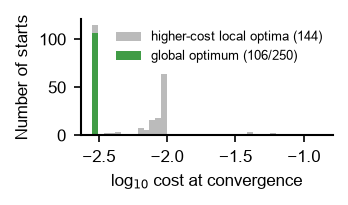

In [4]:
costs = np.array([c for c, _ in ok])
pd.DataFrame(dict(cost=costs, at_global=at_best)).to_csv(
    "table_multistart.csv", index=False
)

# shared bin edges for both histograms: the runs that reach the global optimum all
# land at the same cost (log10 spread < 1e-5), so letting the second hist choose its
# own bins draws it sub-pixel wide and it disappears
edges = np.histogram_bin_edges(np.log10(costs), bins=40)
fig, ax = plt.subplots(figsize=(6 / 2.54, 3.5 / 2.54))
ax.hist(
    np.log10(costs),
    bins=edges,
    color="#bbbbbb",
    edgecolor="none",
    label=f"higher-cost local optima ({(~at_best).sum()})",
)
ax.hist(
    np.log10(costs[at_best]),
    bins=edges,
    color="#419c46",
    edgecolor="none",
    label=f"global optimum ({at_best.sum()}/{len(ok)})",
)
ax.set_xlabel("log$_{10}$ cost at convergence")
ax.set_ylabel("Number of starts")
ax.legend(frameon=False, fontsize=6, loc="upper right")
fig.tight_layout()
fig.savefig(
    "plots/fig_multistart.pdf",
)

## 2. Profile likelihood

Each parameter in turn is held at a series of values above and below its best fit
while the remaining four are re-optimised, recording how much worse the fit becomes.
A parameter that can only be moved a little before the fit deteriorates is well
determined by the data; one that can be moved far at little cost is not.

The cost is the weighted sum of squares $\mathrm{SSE}(\theta)$ over the $n=102$
fitted measurements — the five self-normalisation points at $T=1$ are excluded, see
`polii_model.load_data`. Treating the weighted residuals as Gaussian with a common
unknown scale, $\hat\sigma^2=\mathrm{SSE}_{\min}/(n-p)$ with $p=5$ fitted parameters,
which is the mean squared residual of the fitted model, the profile likelihood-ratio
statistic is

$$\Delta\chi^2(\theta_i)=\left[\mathrm{SSE}(\theta_i)-\mathrm{SSE}_{\min}\right]/\hat\sigma^2$$

and the pointwise 95% confidence interval is the set where
$\Delta\chi^2\le\chi^2_{0.95,1}=3.84$. Note that $\hat\sigma^2$ divides by the number
of measurements, not by the sum of the weights: the weights are relative precisions
that scale the residuals, not replicate counts.

A flat profile would indicate a parameter the data cannot determine at all
(structural non-identifiability); one that rises but never reaches the threshold on a
side is bounded in that direction only (practical non-identifiability).

The premature-termination penalty is kept active while profiling, but only the data
residuals enter $\Delta\chi^2$.

In [5]:
info0 = pm.cost(best, data, full=True, **FIT)
# Residual variance for a weighted least-squares fit: the weighted residual sum
# of squares over (number of measurements - number of fitted parameters).  The
# weights are relative precisions, so they scale the residuals, not the count.
SSE0, NOBS = info0["sse"], info0["n_obs"]
SIG2 = SSE0 / (NOBS - 5)
THRESH = 3.841
print(
    f"SSE_min = {SSE0:.5g}, n = {NOBS:d} measurements, {NOBS - 5:d} residual df, "
    f"sigma^2_hat = {SIG2:.5g}"
)


def outward_grid(x0, lo, hi, n=16, first_step=1.02):
    """Multiplicative grid walking outwards from x0: fine near the optimum
    (2% steps), coarse far away."""
    return (
        np.r_[x0, x0 * np.geomspace(first_step, hi / x0, n)],
        np.r_[x0, x0 * np.geomspace(1 / first_step, lo / x0, n)],
    )


def _cross(xs, ds, thresh):
    """First crossing of `thresh` walking outwards along (xs, ds); linear interp."""
    for k in range(1, len(ds)):
        if ds[k] >= thresh:
            if ds[k] == ds[k - 1]:
                return xs[k]
            t = (thresh - ds[k - 1]) / (ds[k] - ds[k - 1])
            return xs[k - 1] + t * (xs[k] - xs[k - 1])
    return np.nan  # threshold not reached inside the grid


def ci_from_profile(value, dchi2, thresh=THRESH):
    """95% profile-likelihood interval; NaN on a side that never crosses."""
    v, d = np.asarray(value, float), np.asarray(dchi2, float)
    o = np.argsort(v)
    v, d = v[o], d[o]
    i0 = int(np.argmin(d))
    return (
        _cross(v[: i0 + 1][::-1], d[: i0 + 1][::-1], thresh),
        _cross(v[i0:], d[i0:], thresh),
    )


def profile_param(idx, lo, hi, n=16):
    """Profile likelihood for parameter `idx`: fix it, re-optimise the other four,
    walking outwards from the optimum in both directions (warm starts)."""
    rows = []
    up, dn = outward_grid(best[idx], lo, hi, n)
    free = [i for i in range(5) if i != idx]
    for direction in (up, dn):
        x = best.copy()
        for v in direction:
            r = minimize(
                lambda xf: pm.cost(np.insert(xf, idx, v), data, **FIT),
                x[free],
                method="L-BFGS-B",
                bounds=[pm.BOUNDS[i] for i in free],
                options={"maxiter": 2000},
            )
            x = np.insert(r.x, idx, v)
            i2 = pm.cost(x, data, full=True, **FIT)
            s_np, s_pe = pm.saturation(1.0, x)
            rows.append(
                dict(
                    param=pm.PARAM_NAMES[idx],
                    value=v,
                    dchi2=(i2["sse"] - SSE0) / SIG2,
                    penalty=i2["penalty"],
                    s_np=s_np,
                    s_pe=s_pe,
                )
            )
    return pd.DataFrame(rows).sort_values("value")


ranges = {
    "k_pn": (0.2, 10),
    "Vmax_pe": (0.05, 3),
    "Km_pe": (1e-4, 2),
    "Vmax_np": (0.3, 20),
    "Km_np": (0.01, 5),
}
t0 = time.time()
prof = pd.concat([profile_param(i, *ranges[n]) for i, n in enumerate(pm.PARAM_NAMES)])
prof.to_csv("profile_parameters.csv", index=False)
print(
    f"{time.time()-t0:.0f} s; max premature-termination penalty along the "
    f"profiles = {prof.penalty.max():.2e} (cost at optimum {ref['cost']:.2e})"
)

ci = pd.DataFrame(
    [
        dict(
            param=n,
            best=best[i],
            ci_low=ci_from_profile(
                prof.loc[prof.param == n, "value"], prof.loc[prof.param == n, "dchi2"]
            )[0],
            ci_high=ci_from_profile(
                prof.loc[prof.param == n, "value"], prof.loc[prof.param == n, "dchi2"]
            )[1],
        )
        for i, n in enumerate(pm.PARAM_NAMES)
    ]
)
ci["rel_width"] = (ci.ci_high - ci.ci_low) / ci.best
print(ci.round(4).to_string(index=False))

SSE_min = 0.29956, n = 102 measurements, 97 residual df, sigma^2_hat = 0.0030883
93 s; max premature-termination penalty along the profiles = 3.92e-02 (cost at optimum 2.83e-03)
  param   best  ci_low  ci_high  rel_width
   k_pn 4.1367  2.7244   5.8649     0.7592
Vmax_pe 0.3370  0.2827   0.3684     0.2543
  Km_pe 0.0314  0.0190   0.0530     1.0856
Vmax_np 2.7332  2.1280   3.1003     0.3557
  Km_np 0.3186  0.2449   0.4108     0.5205


In [6]:
# The parameter profiles are plotted together with the saturation profiles below
# (Figure S9J), so that this cell only reports the intervals.
for i, name in enumerate(pm.PARAM_NAMES):
    g = prof[prof.param == name]
    lo, hi = ci_from_profile(g.value, g.dchi2)
    print(f"{name:9s} best {best[i]:.4f}  95% profile CI [{lo:.4g}, {hi:.4g}]")

k_pn      best 4.1367  95% profile CI [2.724, 5.865]
Vmax_pe   best 0.3370  95% profile CI [0.2827, 0.3684]
Km_pe     best 0.0314  95% profile CI [0.01895, 0.05302]
Vmax_np   best 2.7332  95% profile CI [2.128, 3.1]
Km_np     best 0.3186  95% profile CI [0.2449, 0.4108]


### Profile likelihood of the saturation levels

More important is the reliability of saturation levels at $T=1$. We therefore profile those
directly. For a grid of target values we re-fit all five parameters under a
strong penalty that fixes $s_{NP}(1)$ (or $s_{PE}(1)$) to the target, and record the
resulting data SSE.

In [7]:
def profile_saturation(which, targets, w=1e4):
    j = 0 if which == "s_np" else 1
    rows, x = [], best.copy()
    for v in targets:
        r = minimize(
            lambda p: pm.cost(p, data, **FIT) + w * (pm.saturation(1.0, p)[j] - v) ** 2,
            x,
            method="L-BFGS-B",
            bounds=pm.BOUNDS,
            options={"maxiter": 4000},
        )
        x = r.x
        i2 = pm.cost(x, data, full=True, **FIT)
        s_np, s_pe = pm.saturation(1.0, x)
        rows.append(
            dict(
                which=which,
                target=v,
                achieved=(s_np, s_pe)[j],
                s_np=s_np,
                s_pe=s_pe,
                T_low=pm.buffering_range(x)[0],
                S_T1=pm.log_sensitivity(x),
                dchi2=(i2["sse"] - SSE0) / SIG2,
                penalty=i2["penalty"],
            )
        )
    return pd.DataFrame(rows)


s_np0, s_pe0 = pm.saturation(1.0, best)


def sat_targets(
    s0,
    step=np.array(
        [
            0.005,
            0.01,
            0.02,
            0.035,
            0.05,
            0.075,
            0.1,
            0.15,
            0.2,
            0.25,
            0.3,
            0.35,
            0.4,
            0.45,
            0.5,
            0.55,
            0.6,
            0.65,
            0.7,
            0.8,
        ]
    ),
):
    """Targets walking outwards from s0, fine nearby, clipped to (0.01, 0.995)."""
    return (np.clip(s0 + step, 0.01, 0.995), np.clip(s0 - step, 0.01, 0.995))


t0 = time.time()
np_up, np_dn = sat_targets(s_np0)
pe_up, pe_dn = sat_targets(s_pe0)
sat = pd.concat(
    [
        profile_saturation("s_np", np_up),
        profile_saturation("s_np", np_dn),
        profile_saturation("s_pe", pe_up),
        profile_saturation("s_pe", pe_dn),
    ]
).sort_values(["which", "target"])
sat.to_csv("profile_saturation.csv", index=False)
print(
    f"{time.time()-t0:.0f} s; worst |achieved - target| = "
    f"{(sat.achieved - sat.target).abs().max():.3f}"
)

for w, lab in [("s_np", "N->P"), ("s_pe", "P->E")]:
    g = sat[sat.which == w]
    lo, hi = ci_from_profile(g.achieved, g.dchi2)
    print(
        f"{lab} saturation at T=1: best {dict(s_np=s_np0, s_pe=s_pe0)[w]:.3f}, "
        f"95% profile CI [{lo:.3f}, {hi:.3f}]"
    )

75 s; worst |achieved - target| = 0.005
N->P saturation at T=1: best 0.557, 95% profile CI [0.492, 0.622]
P->E saturation at T=1: best 0.904, 95% profile CI [0.885, 0.919]


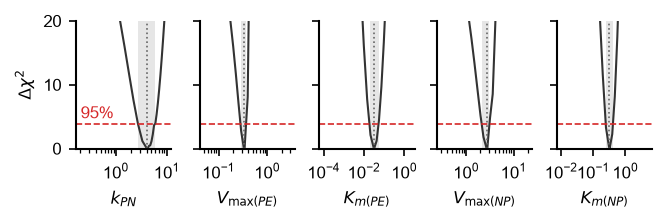

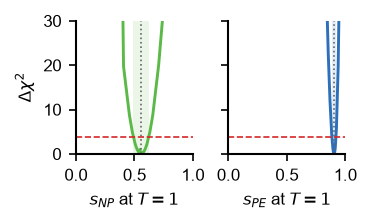

In [8]:
PARAM_LABELS = [
    r"$k_{PN}$",
    r"$V_{\mathrm{max}(PE)}$",
    r"$K_{m(PE)}$",
    r"$V_{\mathrm{max}(NP)}$",
    r"$K_{m(NP)}$",
]

# parameter profiles: 5 panels, 11 cm wide
fig1 = plt.figure(figsize=(11 / 2.54, 3.5 / 2.54), layout="constrained")
gs1 = fig1.add_gridspec(1, 5, wspace=0.05)
pax = [fig1.add_subplot(gs1[0, k]) for k in range(5)]
for ax, (i, label) in zip(pax, enumerate(PARAM_LABELS)):
    g = prof[prof.param == pm.PARAM_NAMES[i]]
    lo, hi = ci_from_profile(g.value, g.dchi2)
    ax.plot(g.value, g.dchi2, color="#333333", lw=1)
    ax.axhline(THRESH, color="#d62728", lw=0.8, ls="--")
    ax.axvline(best[i], color="#666666", lw=0.8, ls=":")
    ax.axvspan(lo, hi, color="#333333", alpha=0.12, lw=0)
    ax.set_xscale("log")
    ax.set_ylim(0, 20)
    ax.set_xlabel(label, fontsize=8)
    ax.tick_params(labelsize=8)
    ax.xaxis.set_major_locator(plt.LogLocator(numticks=4))
    if ax is not pax[0]:
        ax.tick_params(labelleft=False)
pax[0].set_ylabel(r"$\Delta\chi^2$", fontsize=8)
pax[0].text(
    0.05,
    THRESH + 0.9,
    "95%",
    color="#d62728",
    fontsize=8,
    transform=pax[0].get_yaxis_transform(),
)
fig1.savefig("plots/fig_profiles_params.pdf")

# saturation profiles: 2 panels, 5 cm wide
fig2 = plt.figure(figsize=(6 / 2.54, 3.5 / 2.54), layout="constrained")
gs2 = fig2.add_gridspec(1, 2, wspace=0.05)
sax = [fig2.add_subplot(gs2[0, 0]), fig2.add_subplot(gs2[0, 1])]
for ax, (w, lab, col, b) in zip(
    sax,
    [
        ("s_np", r"$s_{NP}$ at $T = 1$", C_NP, s_np0),
        ("s_pe", r"$s_{PE}$ at $T = 1$", C_PE, s_pe0),
    ],
):
    g = sat[sat.which == w]
    ax.plot(g.achieved, g.dchi2, color=col, lw=1.4)
    ax.axhline(THRESH, color="#d62728", lw=0.8, ls="--")
    ax.axvline(b, color="#666666", lw=0.8, ls=":")
    lo, hi = ci_from_profile(g.achieved, g.dchi2)
    ax.axvspan(lo, hi, color=col, alpha=0.12, lw=0)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 30)
    ax.set_xlabel(lab, fontsize=8)
    ax.tick_params(labelsize=8)
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
sax[1].tick_params(labelleft=False)
sax[0].set_ylabel(r"$\Delta\chi^2$", fontsize=8)
fig2.savefig("plots/fig_profiles_sat.pdf")

### Two-dimensional profile in the two Michaelis constants

$K_{m(NP)}$ and $K_{m(PE)}$ are the parameters that set the two saturation levels.
Fixing both on a grid and re-optimising the remaining three parameters gives the
joint confidence region ($\Delta\chi^2\le\chi^2_{0.95,2}=5.99$).

156 s


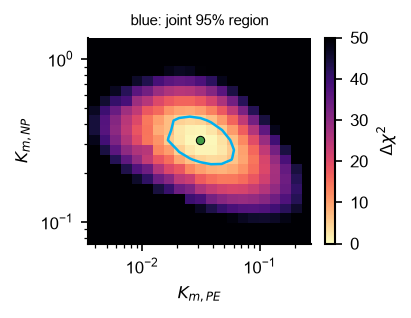

In [9]:
def profile_2d(g_np, g_pe):
    Z = np.full((len(g_np), len(g_pe)), np.nan)
    for i, a in enumerate(g_np):
        x = best.copy()
        for j, b in enumerate(g_pe):
            r = minimize(
                lambda xf: pm.cost(np.r_[xf[0], xf[1], b, xf[2], a], data, **FIT),
                x[[0, 1, 3]],
                method="L-BFGS-B",
                bounds=[pm.BOUNDS[k] for k in (0, 1, 3)],
                options={"maxiter": 2000},
            )
            x = np.r_[r.x[0], r.x[1], b, r.x[2], a]
            Z[i, j] = (pm.cost(x, data, full=True, **FIT)["sse"] - SSE0) / SIG2
    return Z


g_np = np.geomspace(best[4] / 4, best[4] * 4, 21)
g_pe = np.geomspace(best[2] / 8, best[2] * 8, 21)
t0 = time.time()
Z = profile_2d(g_np, g_pe)
print(f"{time.time()-t0:.0f} s")

fig, ax = plt.subplots(figsize=(7 / 2.54, 5.5 / 2.54))
im = ax.pcolormesh(g_pe, g_np, np.clip(Z, 0, 50), cmap="magma_r", shading="nearest")
ax.contour(g_pe, g_np, Z, levels=[5.991], colors="#00b0f0", linewidths=1.2)
ax.plot(best[2], best[4], "o", ms=4, mfc="#419c46", mec="k", mew=0.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("$K_{m,PE}$")
ax.set_ylabel("$K_{m,NP}$")
fig.colorbar(im, ax=ax, label=r"$\Delta\chi^2$")
ax.set_title("blue: joint 95% region", fontsize=7)
fig.tight_layout()
fig.savefig("fig_profile_2d.pdf")

## 3. Bootstrap resampling

Rows are resampled with replacement within each imaging and each FRAP dataset
(stratified case resampling), so the intervals below describe the sampling
variability of the imaging and FRAP measurements. The two dxChIP-seq points are
held fixed — resampling two points with replacement is degenerate — and their
influence is examined directly in section 4 instead.

In [10]:
def resample(rng):
    """Case resampling, stratified by dataset (imaging and FRAP blocks)."""
    b = dict(data)
    for key, cols in (
        ("E_block", ("T_E", "E", "E_sd", "E_fit")),
        ("B_block", ("T_B", "B")),
    ):
        idx = np.concatenate(
            [
                rng.choice(
                    np.where(data[key] == g)[0],
                    (data[key] == g).sum(),
                    replace=True,
                )
                for g in np.unique(data[key])
            ]
        )
        for c in cols:
            b[c] = data[c][idx]
        b[key] = data[key][idx]
    return b


t0, rows = time.time(), []
rng = np.random.default_rng(2024)
for i in range(300):
    b = resample(rng)
    r = pm.fit(b, n_starts=1, seed=i, x0=best, **FIT)
    rows.append({**pm.summarise(r["params"], b, **FIT), "rep": i})
boot = pd.DataFrame(rows)
boot.to_csv("table_bootstrap_draws.csv", index=False)
print(f"{time.time()-t0:.0f} s")

cols = [
    "s_np_T1.0",
    "s_pe_T1.0",
    "s_np_T0.7",
    "s_pe_T0.7",
    "T_low",
    "S_T1",
    "Km_np",
    "Km_pe",
    "P0",
]
print(boot[cols].quantile([0.025, 0.5, 0.975]).round(3).to_string())
print(
    "P->E more saturated than N->P in %.1f%% of replicates; P->E > 0.8 in %.1f%%"
    % (
        100 * (boot["s_pe_T1.0"] > boot["s_np_T1.0"]).mean(),
        100 * (boot["s_pe_T1.0"] > 0.8).mean(),
    )
)

716 s
       s_np_T1.0  s_pe_T1.0  s_np_T0.7  s_pe_T0.7  T_low   S_T1  Km_np  Km_pe     P0
0.025      0.544      0.888      0.391      0.842  0.666  0.079  0.301  0.025  0.268
0.500      0.558      0.904      0.402      0.862  0.686  0.090  0.318  0.031  0.294
0.975      0.569      0.917      0.413      0.879  0.707  0.103  0.340  0.041  0.330
P->E more saturated than N->P in 100.0% of replicates; P->E > 0.8 in 100.0%


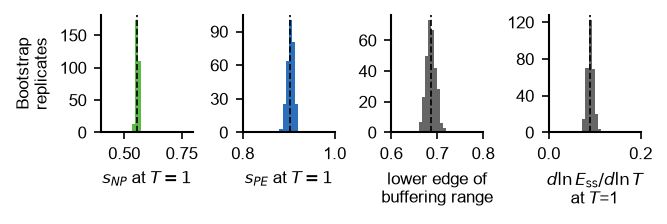

In [11]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(11 / 2.54, 3.5 / 2.54),
    layout="constrained",
    gridspec_kw={"wspace": 0.05},
)
panels = [
    ("s_np_T1.0", r"$s_{NP}$ at $T=1$", (0.4, 0.8), C_NP),
    ("s_pe_T1.0", r"$s_{PE}$ at $T=1$", (0.8, 1.0), C_PE),
    ("T_low", "lower edge of\nbuffering range", (0.6, 0.8), "#666666"),
    ("S_T1", r"$d\ln E_{\rm ss}/d\ln T$" + "\nat $T$=1", (0.0, 0.2), "#666666"),
]
for k, (ax, (c, lab, xl, col)) in enumerate(zip(axes, panels)):
    ax.hist(boot[c].dropna(), bins=30, range=xl, color=col, lw=0)
    ax.axvline(pm.summarise(best, data, **FIT)[c], color="k", lw=0.8, ls="--")
    ax.set_xlabel(lab)
    ax.set_xlim(*xl)
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=4, integer=True))
    if k == 2:
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
axes[0].set_ylabel("Bootstrap\nreplicates")
fig.savefig("plots/fig_bootstrap.pdf")

## 4. Influence of the dxChIP-seq measurements

The two dxChIP-seq points are the only genomic measurements in the fit and carry a
threefold weight, so it is worth asking directly how much the saturation estimates
depend on them. Rather than resample them, we profile over their *values*: each
measurement in turn is fixed at a grid of assumed values, all five parameters are
refitted at each, and the resulting saturation levels are recorded. This is the same
construction as the parameter profiles in section 2, applied to a measurement rather
than a parameter.

The grey band marks ±10% of the measured value — far wider than the sampling
precision of these summaries, which is ±0.2% by bootstrap over genes.

We also refit with each point omitted, and with both omitted.

In [12]:
LBL = {0: "half-degron 90 min ($T$ = 0.738)", 1: "ARMC5 KO ($T$ = 1.51)"}
FITROW = np.where(data["P_fit"])[0]  # the two real dxChIP-seq points


def profile_chip_value(j, grid):
    """Fix dxChIP-seq measurement `j` at each value in `grid` and refit."""
    out, x = [], best.copy()
    for v in grid:
        b = dict(data)
        P = data["P"].copy()
        P[FITROW[j]] = v
        b["P"] = P
        r = pm.fit(b, n_starts=4, seed=9, x0=x, **FIT)
        x = r["params"]
        s = pm.summarise(x, b, **FIT)
        out.append(
            dict(
                point=LBL[j],
                value=v,
                measured=data["P"][FITROW[j]],
                s_np=s["s_np_T1.0"],
                s_pe=s["s_pe_T1.0"],
                T_low=s["T_low"],
                S_T1=s["S_T1"],
            )
        )
    return pd.DataFrame(out)


# scan +/-20% around each measured value
grids = {
    j: np.round(np.linspace(0.8 * v, 1.2 * v, 33), 4)
    for j, v in enumerate(data["P"][np.where(data["P_fit"])[0]])
}
t0, parts = time.time(), []
for j, g in grids.items():
    m = data["P"][FITROW[j]]
    parts += [profile_chip_value(j, g[g >= m]), profile_chip_value(j, g[g <= m][::-1])]
    print(f"{LBL[j]}: scanned {g.min():.3f}-{g.max():.3f}", flush=True)
chip = (
    pd.concat(parts).drop_duplicates(["point", "value"]).sort_values(["point", "value"])
)
chip.to_csv("table_chip_value_profile.csv", index=False)
print(f"{time.time()-t0:.0f} s")
for pt, g in chip.groupby("point"):
    m = g.measured.iloc[0]
    w = g[(g.value >= 0.9 * m) & (g.value <= 1.1 * m)]
    print(
        f"{pt}: within +/-10% of the measured value, "
        f"N->P {w.s_np.min():.3f}-{w.s_np.max():.3f}, P->E {w.s_pe.min():.3f}-{w.s_pe.max():.3f}"
    )

half-degron 90 min ($T$ = 0.738): scanned 0.727-1.091
ARMC5 KO ($T$ = 1.51): scanned 1.160-1.740
481 s
ARMC5 KO ($T$ = 1.51): within +/-10% of the measured value, N->P 0.412-0.703, P->E 0.855-0.931
half-degron 90 min ($T$ = 0.738): within +/-10% of the measured value, N->P 0.525-0.596, P->E 0.884-0.920


In [13]:
rows = [
    dict(
        variant="as reported",
        **{
            c: pm.summarise(best, data, **FIT)[c]
            for c in ("s_np_T1.0", "s_pe_T1.0", "T_low", "S_T1")
        }
    )
]
for j in (0, 1):
    b = dict(data)
    keep = data["P_fit"].copy()
    keep[FITROW[j]] = False
    b["P_fit"] = keep
    r = pm.fit(b, n_starts=60, seed=3, x0=best, **FIT)
    s = pm.summarise(r["params"], b, **FIT)
    rows.append(
        dict(
            variant="omit " + LBL[j],
            **{c: s[c] for c in ("s_np_T1.0", "s_pe_T1.0", "T_low", "S_T1")}
        )
    )
r = pm.fit(data, n_starts=60, seed=3, x0=best, w_P=0.0, pt_fraction=0.8)
s = pm.summarise(r["params"], data, w_P=0.0, pt_fraction=0.8)
rows.append(
    dict(
        variant="omit both (dxChIP-seq excluded)",
        **{c: s[c] for c in ("s_np_T1.0", "s_pe_T1.0", "T_low", "S_T1")}
    )
)
loo = pd.DataFrame(rows)
loo.to_csv("table_chip_leave_one_out.csv", index=False)
print(loo.round(4).to_string(index=False))

                              variant  s_np_T1.0  s_pe_T1.0  T_low   S_T1
                          as reported     0.5572     0.9037 0.6870 0.0904
omit half-degron 90 min ($T$ = 0.738)     0.4789     0.9414 0.6487 0.0661
           omit ARMC5 KO ($T$ = 1.51)     0.8757     0.6504 0.7126 0.1000
      omit both (dxChIP-seq excluded)     0.7215     0.8644 0.6876 0.0870


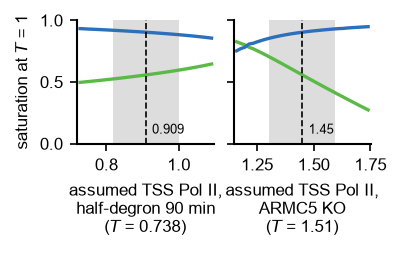

In [14]:
fig, axes = plt.subplots(
    1, 2, figsize=(6.5 / 2.54, 4 / 2.54), sharey=True, layout="constrained"
)
for ax, j in zip(axes, (0, 1)):
    g = chip[chip.point == LBL[j]].sort_values("value")
    m = g.measured.iloc[0]
    ax.axvspan(0.9 * m, 1.1 * m, color="#dddddd", lw=0, zorder=0)
    ax.plot(g.value, g.s_np, "-", color=C_NP, lw=1.6)
    ax.plot(g.value, g.s_pe, "-", color=C_PE, lw=1.6)
    ax.axvline(m, color="k", lw=0.8, ls="--")
    ax.set_xlabel(f"assumed TSS Pol II,\n{LBL[j]}".replace(" ($T$", "\n($T$"))
    ax.set_ylim(0, 1)
    ax.margins(x=0.02)
    ax.annotate(
        f"{m}",
        xy=(m, 0.06),
        xytext=(3, 0),
        textcoords="offset points",
        fontsize=6,
        va="bottom",
    )
axes[0].set_ylabel("saturation at $T$ = 1")
fig.savefig("plots/fig_chip_influence.pdf")

## 5. Summary table

In [15]:
out = []
for c, lab in [
    ("s_np_T1.0", "N→P saturation at T=1"),
    ("s_pe_T1.0", "P→E saturation at T=1"),
    ("s_np_T0.7", "N→P saturation at T=0.7"),
    ("s_pe_T0.7", "P→E saturation at T=0.7"),
    ("T_low", "lower edge of buffering range"),
    ("S_T1", "dlnE/dlnT at T=1"),
    ("Km_np", "Km,NP"),
    ("Km_pe", "Km,PE"),
    ("P0", "P at T=1"),
]:
    v = boot[c].dropna()
    lo, hi = np.percentile(v, [2.5, 97.5])
    out.append(
        dict(
            quantity=lab,
            best_fit=pm.summarise(best, data, **FIT)[c],
            boot_cases_2_5=lo,
            boot_cases_97_5=hi,
        )
    )
summary_table = pd.DataFrame(out)
for w, c in (("s_np", "N→P saturation at T=1"), ("s_pe", "P→E saturation at T=1")):
    g = sat[sat.which == w]
    lo, hi = ci_from_profile(g.achieved, g.dchi2)
    summary_table.loc[summary_table.quantity == c, "profile_2_5"] = lo
    summary_table.loc[summary_table.quantity == c, "profile_97_5"] = hi
summary_table.to_csv("table_identifiability.csv", index=False)
print(summary_table.round(3).to_string(index=False))

                     quantity  best_fit  boot_cases_2_5  boot_cases_97_5  profile_2_5  profile_97_5
        N→P saturation at T=1     0.557           0.544            0.569        0.492         0.622
        P→E saturation at T=1     0.904           0.888            0.917        0.885         0.919
      N→P saturation at T=0.7     0.402           0.391            0.413          NaN           NaN
      P→E saturation at T=0.7     0.862           0.842            0.879          NaN           NaN
lower edge of buffering range     0.687           0.666            0.707          NaN           NaN
             dlnE/dlnT at T=1     0.090           0.079            0.103          NaN           NaN
                        Km,NP     0.319           0.301            0.340          NaN           NaN
                        Km,PE     0.031           0.025            0.041          NaN           NaN
                     P at T=1     0.295           0.268            0.330          NaN           NaN
